In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer


In [4]:
# Load the dataset
data = pd.read_csv('Chennai.csv')

# Display the first few rows
print(data.head())

# Basic info and stats
print(data.info())
print(data.describe())


      Price  Area        Location  No. of Bedrooms  Resale  MaintenanceStaff  \
0   5500000  1310   Perungalathur                3       0                 0   
1   5350000  1126      Madhavaram                2       0                 0   
2   8205000  1307      Karapakkam                3       0                 0   
3  23400000  3600  Thiruvidandhai                3       0                 0   
4  10100000  1700  Iyappanthangal                3       0                 0   

   Gymnasium  SwimmingPool  LandscapedGardens  JoggingTrack  ...  \
0          0             0                  0             0  ...   
1          1             1                  1             0  ...   
2          1             1                  1             1  ...   
3          1             1                  0             1  ...   
4          1             1                  1             1  ...   

   LiftAvailable  BED  VaastuCompliant  Microwave  GolfCourse  TV  \
0              0    0                0   

In [5]:
# Replace '9' with NaN for missing values
data.replace(9, np.nan, inplace=True)

# Drop irrelevant columns
columns_to_drop = ['Location']  # Add more columns if needed
data.drop(columns=columns_to_drop, inplace=True)

# Handle missing values (numerical and categorical separately)
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

for col in data.select_dtypes(include=['float64', 'int64']):
    data[col] = imputer_num.fit_transform(data[[col]])

for col in data.select_dtypes(include=['object']):
    data[col] = imputer_cat.fit_transform(data[[col]])

# Confirm no missing values
print(data.isnull().sum())


Price                  0
Area                   0
No. of Bedrooms        0
Resale                 0
MaintenanceStaff       0
Gymnasium              0
SwimmingPool           0
LandscapedGardens      0
JoggingTrack           0
RainWaterHarvesting    0
IndoorGames            0
ShoppingMall           0
Intercom               0
SportsFacility         0
ATM                    0
ClubHouse              0
School                 0
24X7Security           0
PowerBackup            0
CarParking             0
StaffQuarter           0
Cafeteria              0
MultipurposeRoom       0
Hospital               0
WashingMachine         0
Gasconnection          0
AC                     0
Wifi                   0
Children'splayarea     0
LiftAvailable          0
BED                    0
VaastuCompliant        0
Microwave              0
GolfCourse             0
TV                     0
DiningTable            0
Sofa                   0
Wardrobe               0
Refrigerator           0
dtype: int64


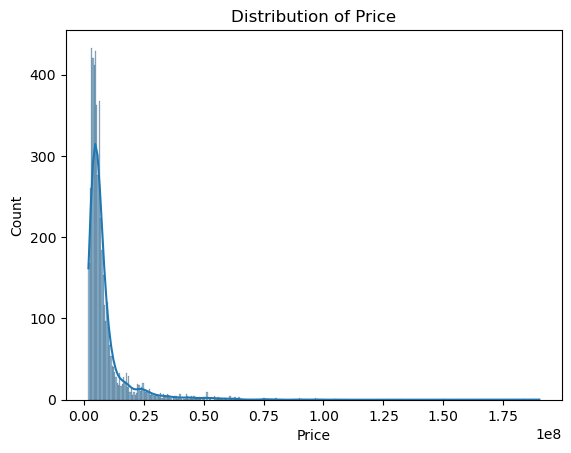

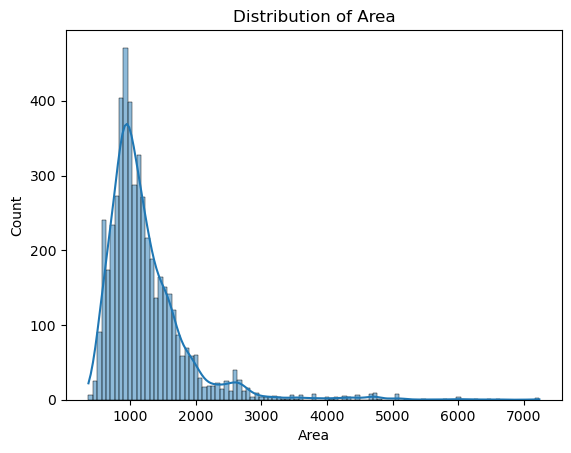

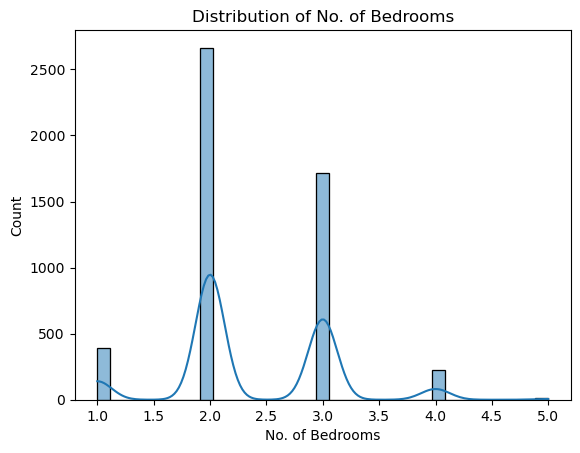

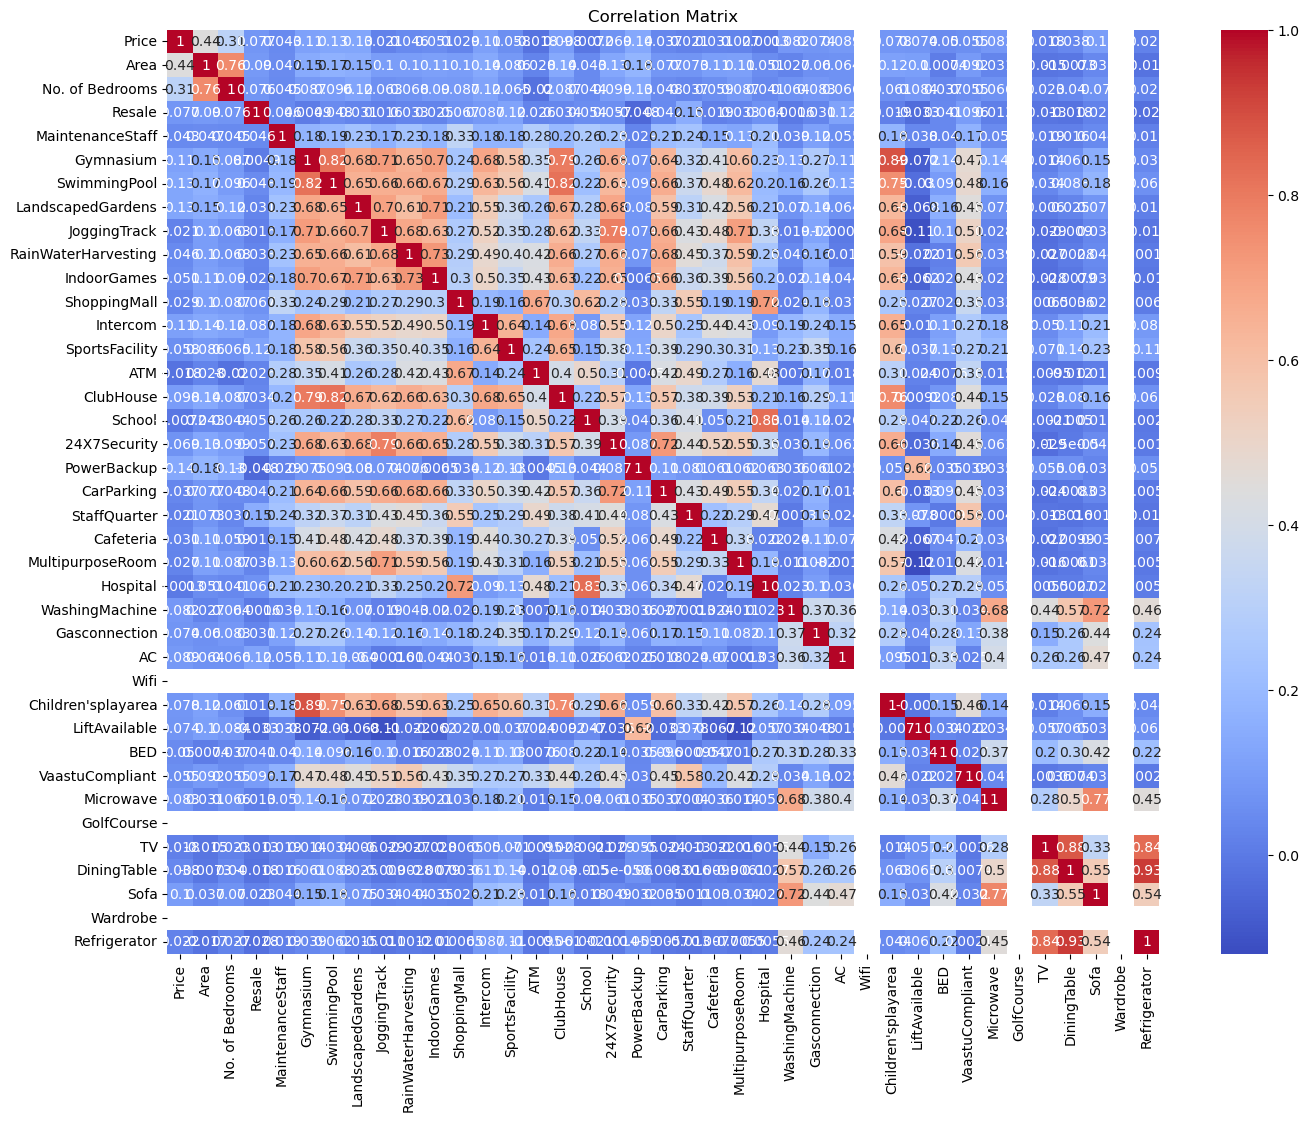

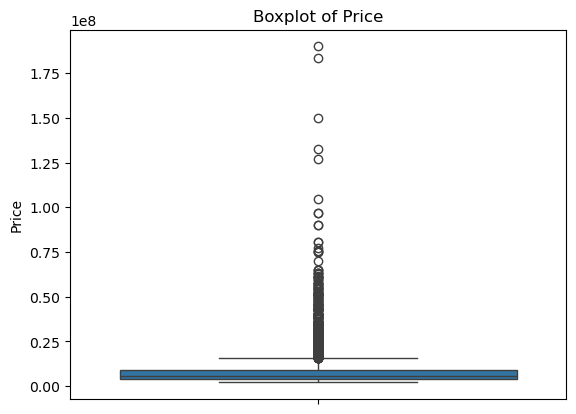

In [6]:
# Plot distributions
for col in ['Price', 'Area', 'No. of Bedrooms']:
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Correlation heatmap
corr_matrix = data.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Boxplot for outlier detection
sns.boxplot(data['Price'])
plt.title('Boxplot of Price')
plt.show()


In [7]:
# Encode categorical variables
label_encoder = LabelEncoder()
for col in data.select_dtypes(include=['object']):
    data[col] = label_encoder.fit_transform(data[col])

# Feature-target split
X = data.drop('Price', axis=1)
y = data['Price']

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


                Feature  Importance
0                  Area    0.719035
1       No. of Bedrooms    0.054882
4             Gymnasium    0.029509
2                Resale    0.021157
18           CarParking    0.019455
6     LandscapedGardens    0.017699
28        LiftAvailable    0.015072
27   Children'splayarea    0.014721
8   RainWaterHarvesting    0.013416
20            Cafeteria    0.013054
5          SwimmingPool    0.010362
11             Intercom    0.009924
17          PowerBackup    0.009118
21     MultipurposeRoom    0.009017
7          JoggingTrack    0.006622
30      VaastuCompliant    0.004953
9           IndoorGames    0.004610
16         24X7Security    0.003584
12       SportsFacility    0.003430
14            ClubHouse    0.003169
34          DiningTable    0.002599
35                 Sofa    0.002461
24        Gasconnection    0.002373
3      MaintenanceStaff    0.002065
29                  BED    0.001651
19         StaffQuarter    0.001130
23       WashingMachine    0

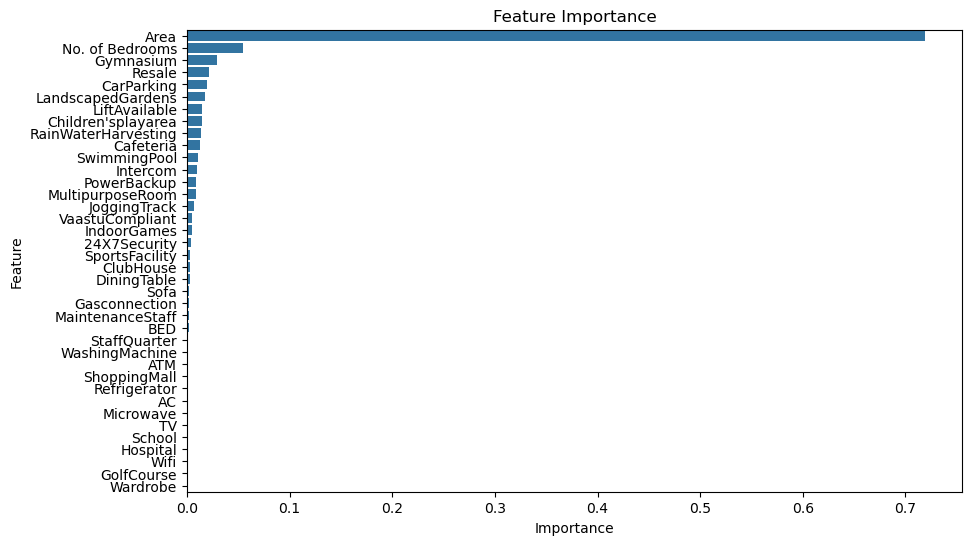

In [9]:
# Train a Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Feature importance
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)
print(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance')
plt.show()


In [10]:
# Predictions
y_pred = rf_model.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R²: {r2}")


RMSE: 10050120.142871235
MAE: 4020180.4607422426
R²: 0.28269873749744867


In [11]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2)
grid_search.fit(X_train, y_train)

# Best parameters
print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate the tuned model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned RMSE: {rmse_tuned}")
print(f"Tuned MAE: {mae_tuned}")
print(f"Tuned R²: {r2_tuned}")


Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   1.6s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   1.6s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   1.7s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   1.6s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=   1.6s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   3.3s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   3.4s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   3.4s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   3.3s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=   3.7s
[CV] END max_depth=None, min_samples_split=2, n_estimators=300; total time=   5.4s
[CV] END max_depth=None, 

In [12]:
import joblib

# Save the trained model
joblib.dump(best_model, 'chennai_house_price_model.pkl')
print("Model saved successfully.")


Model saved successfully.
